In [11]:
import os
import re
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

from dotenv import load_dotenv
from IPython.display import display
from sklearn.manifold import MDS
from sklearn.metrics import pairwise_distances

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


In [12]:
# Localiza a pasta AULA_03
PASTA_AULA = Path.cwd()

if PASTA_AULA.name != "AULA_03":
    PASTA_AULA = PASTA_AULA / "AULA_03"

CAMINHO_ENV = PASTA_AULA / ".env"

load_dotenv(CAMINHO_ENV)

OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")
MODELO_EMBEDDING = os.getenv(
    "EMBEDDING_MODEL",
    "nvidia/nemotron-3-embed-1b:free"
)

if not OPENROUTER_API_KEY:
    raise RuntimeError(
        "A chave OPENROUTER_API_KEY não foi encontrada no .env."
    )

print("Pasta da aula:", PASTA_AULA)
print("Arquivo .env encontrado:", CAMINHO_ENV.exists())
print("Chave carregada:", bool(OPENROUTER_API_KEY))
print("Modelo:", MODELO_EMBEDDING)

Pasta da aula: c:\Users\Fernanda Fregulha\Downloads\IA\IA\AULA_03
Arquivo .env encontrado: True
Chave carregada: True
Modelo: nvidia/nemotron-3-embed-1b:free


In [13]:
URL_EMBEDDINGS = "https://openrouter.ai/api/v1/embeddings"

# Guarda embeddings já gerados durante esta execução.
# Isso evita chamar a API novamente para o mesmo texto.
cache_embeddings = {}


def get_embeddings(textos):
    """
    Recebe uma lista de textos e devolve uma lista de embeddings.
    Os textos ainda não processados são enviados juntos ao OpenRouter.
    """
    if isinstance(textos, str):
        textos = [textos]

    textos = [texto.strip() for texto in textos]

    if not textos or any(not texto for texto in textos):
        raise ValueError("Os textos não podem estar vazios.")

    # Remove repetições e seleciona somente o que ainda não está no cache
    textos_faltantes = list(
        dict.fromkeys(
            texto for texto in textos
            if texto not in cache_embeddings
        )
    )

    if textos_faltantes:
        headers = {
            "Authorization": f"Bearer {OPENROUTER_API_KEY}",
            "Content-Type": "application/json"
        }

        dados_enviados = {
            "model": MODELO_EMBEDDING,
            "input": textos_faltantes
        }

        resposta = requests.post(
            URL_EMBEDDINGS,
            headers=headers,
            json=dados_enviados,
            timeout=120
        )

        if not resposta.ok:
            raise RuntimeError(
                f"Erro {resposta.status_code}: {resposta.text}"
            )

        dados_recebidos = resposta.json()

        # Garante a ordem original dos resultados
        embeddings_recebidos = sorted(
            dados_recebidos["data"],
            key=lambda item: item["index"]
        )

        for texto, item in zip(
            textos_faltantes,
            embeddings_recebidos
        ):
            cache_embeddings[texto] = np.array(
                item["embedding"],
                dtype=np.float32
            )

    return [
        cache_embeddings[texto].copy()
        for texto in textos
    ]


def get_embedding(texto):
    """
    Versão para somente um texto, conforme solicitado na atividade.
    """
    return get_embeddings([texto])[0]

In [14]:
embedding_teste = get_embedding("gato")

print("Tipo:", type(embedding_teste))
print("Dimensão:", len(embedding_teste))
print("Primeiros 10 números:")
print(embedding_teste[:10])

Tipo: <class 'numpy.ndarray'>
Dimensão: 2048
Primeiros 10 números:
[-0.01016381 -0.09622478 -0.00740191  0.          0.01621238  0.03132
 -0.03916381 -0.0030381  -0.02124941 -0.01701333]


In [15]:
def validar_embeddings(embedding_a, embedding_b):
    """
    Converte os embeddings para NumPy e verifica se possuem
    a mesma dimensão.
    """
    vetor_a = np.asarray(embedding_a, dtype=np.float64)
    vetor_b = np.asarray(embedding_b, dtype=np.float64)

    if vetor_a.ndim != 1 or vetor_b.ndim != 1:
        raise ValueError(
            "Cada embedding deve ser um vetor unidimensional."
        )

    if vetor_a.size == 0 or vetor_b.size == 0:
        raise ValueError("Os embeddings não podem estar vazios.")

    if vetor_a.shape != vetor_b.shape:
        raise ValueError(
            "Os embeddings devem possuir a mesma dimensão."
        )

    return vetor_a, vetor_b


def distancia_euclidiana(embedding_a, embedding_b):
    """
    Calcula a raiz quadrada da soma das diferenças ao quadrado.
    """
    vetor_a, vetor_b = validar_embeddings(
        embedding_a,
        embedding_b
    )

    diferencas = vetor_a - vetor_b
    soma_dos_quadrados = np.sum(diferencas ** 2)

    return float(np.sqrt(soma_dos_quadrados))


def similaridade_cosseno(embedding_a, embedding_b):
    """
    Calcula o cosseno do ângulo entre os dois vetores.
    Quanto mais próximo de 1, mais similares são os vetores.
    """
    vetor_a, vetor_b = validar_embeddings(
        embedding_a,
        embedding_b
    )

    norma_a = np.linalg.norm(vetor_a)
    norma_b = np.linalg.norm(vetor_b)

    if norma_a == 0 or norma_b == 0:
        raise ValueError(
            "Não é possível calcular cosseno com vetor nulo."
        )

    similaridade = np.dot(vetor_a, vetor_b) / (
        norma_a * norma_b
    )

    # Evita pequenas imprecisões de ponto flutuante
    return float(np.clip(similaridade, -1.0, 1.0))


def distancia_cosseno(embedding_a, embedding_b):
    """
    Distância de cosseno = 1 - similaridade de cosseno.
    Quanto menor, mais similares são os vetores.
    """
    return 1.0 - similaridade_cosseno(
        embedding_a,
        embedding_b
    )

In [16]:
embedding_a = [1, 0, 0]
embedding_b = [0, 1, 0]
embedding_c = [1, 0, 0]

pares_teste = [
    ("embedding_a", embedding_a, "embedding_b", embedding_b),
    ("embedding_a", embedding_a, "embedding_c", embedding_c),
    ("embedding_b", embedding_b, "embedding_c", embedding_c)
]

resultados_teste = []

for nome_a, vetor_a, nome_b, vetor_b in pares_teste:
    resultados_teste.append({
        "Par": f"{nome_a} x {nome_b}",
        "Distância Euclidiana": round(
            distancia_euclidiana(vetor_a, vetor_b),
            4
        ),
        "Similaridade Cosseno": round(
            similaridade_cosseno(vetor_a, vetor_b),
            4
        ),
        "Distância Cosseno": round(
            distancia_cosseno(vetor_a, vetor_b),
            4
        )
    })

df_testes = pd.DataFrame(resultados_teste)
df_testes

,Par,Distância Euclidiana,Similaridade Cosseno,Distância Cosseno
0,embedding_a x embedding_b,1.4142,0.0,1.0
1,embedding_a x embedding_c,0.0000,1.0,0.0
2,embedding_b x embedding_c,1.4142,0.0,1.0


In [17]:
termos = [
    "gato",
    "felino",
    "cachorro",
    "carro",
    "caminhão",
    "moto",
    "banana",
    "maçã",
    "goiaba"
]

vetores_termos = get_embeddings(termos)

print("Quantidade de termos:", len(termos))
print("Quantidade de embeddings:", len(vetores_termos))
print("Dimensão de cada embedding:", len(vetores_termos[0]))

Quantidade de termos: 9
Quantidade de embeddings: 9
Dimensão de cada embedding: 2048


In [18]:
resultados_termos = []

for indice_a in range(len(termos)):
    for indice_b in range(indice_a + 1, len(termos)):
        termo_a = termos[indice_a]
        termo_b = termos[indice_b]

        vetor_a = vetores_termos[indice_a]
        vetor_b = vetores_termos[indice_b]

        resultados_termos.append({
            "Termo A": termo_a,
            "Termo B": termo_b,
            "Dist. Euclidiana": round(
                distancia_euclidiana(vetor_a, vetor_b),
                4
            ),
            "Similaridade Cosseno": round(
                similaridade_cosseno(vetor_a, vetor_b),
                4
            ),
            "Distância Cosseno": round(
                distancia_cosseno(vetor_a, vetor_b),
                4
            )
        })

df_termos = pd.DataFrame(resultados_termos)

# Maior similaridade primeiro
df_termos = df_termos.sort_values(
    "Similaridade Cosseno",
    ascending=False
).reset_index(drop=True)

df_termos

,Termo A,Termo B,Dist. Euclidiana,Similaridade Cosseno,Distância Cosseno
0,cachorro,carro,1.0245,0.4752,0.5248
1,carro,caminhão,1.0526,0.4460,0.5540
2,gato,moto,1.0782,0.4187,0.5813
3,gato,cachorro,1.0931,0.4026,0.5974
4,banana,maçã,1.1021,0.3927,0.6073
5,gato,felino,1.1179,0.3752,0.6248
6,carro,moto,1.1200,0.3728,0.6272
7,cachorro,caminhão,1.1372,0.3534,0.6466
8,gato,carro,1.1397,0.3505,0.6495
9,felino,cachorro,1.1406,0.3495,0.6505


c:\Users\Fernanda Fregulha\Downloads\IA\IA\venv\Lib\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
c:\Users\Fernanda Fregulha\Downloads\IA\IA\venv\Lib\site-packages\sklearn\manifold\_mds.py:752: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


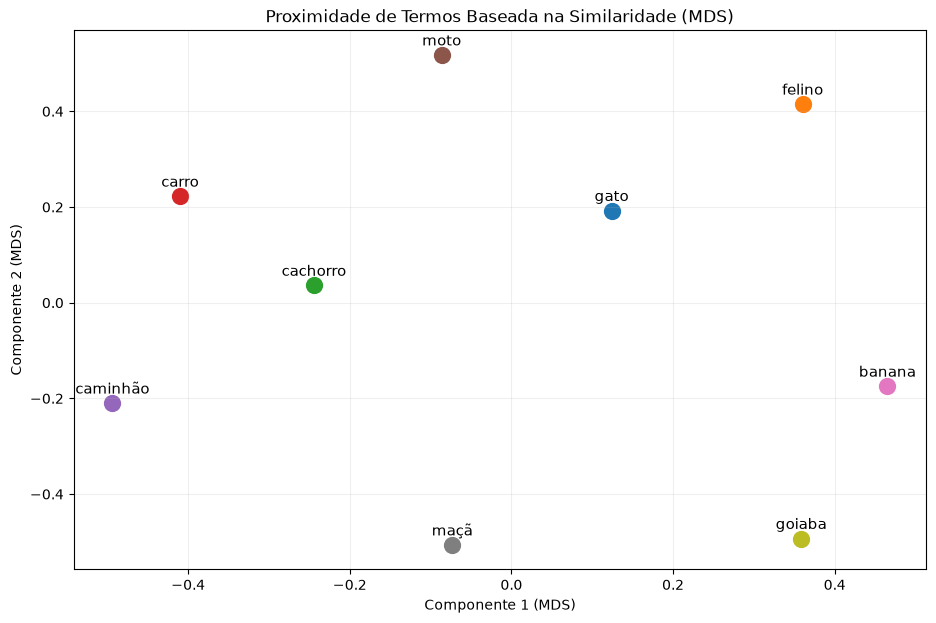

In [19]:
matriz_vetores = np.array(vetores_termos)

# Calcula a distância de cosseno entre todos os termos
matriz_distancias = pairwise_distances(
    matriz_vetores,
    metric="cosine"
)

# Reduz os embeddings para duas dimensões
mds = MDS(
    n_components=2,
    dissimilarity="precomputed",
    random_state=42
)

coordenadas = mds.fit_transform(matriz_distancias)

plt.figure(figsize=(11, 7))

for indice, termo in enumerate(termos):
    x = coordenadas[indice, 0]
    y = coordenadas[indice, 1]

    plt.scatter(x, y, s=130)
    plt.text(
        x,
        y + 0.02,
        termo,
        ha="center",
        fontsize=11
    )

plt.title("Proximidade de Termos Baseada na Similaridade (MDS)")
plt.xlabel("Componente 1 (MDS)")
plt.ylabel("Componente 2 (MDS)")
plt.grid(alpha=0.2)
plt.show()

In [20]:
frase_ancora = (
    "O cachorro correu no parque e brincou com a bola."
)

frases_comparacao = [
    (
        "Similar (mesmo sentido, palavras diferentes)",
        "Um cão estava correndo no jardim e brincando "
        "com seu brinquedo."
    ),
    (
        "Relacionado (mesmo contexto de animais)",
        "O gato dormiu na almofada da sala durante "
        "toda a tarde."
    ),
    (
        "Diferente (outro domínio - economia)",
        "A taxa de juros do banco central subiu "
        "dois pontos percentuais."
    ),
    (
        "Oposto/Negação",
        "Nenhum animal esteve no parque e o cão "
        "permaneceu preso em casa."
    )
]

vec_ancora = get_embedding(frase_ancora)

textos_comparacao = [
    texto
    for categoria, texto in frases_comparacao
]

vecs_comparacao = get_embeddings(textos_comparacao)

In [21]:
resultados_frases = []

for (categoria, texto), vetor in zip(
    frases_comparacao,
    vecs_comparacao
):
    resultados_frases.append({
        "Categoria": categoria,
        "Texto": texto,
        "Dist. Euclidiana": round(
            distancia_euclidiana(vec_ancora, vetor),
            4
        ),
        "Similaridade Cosseno": round(
            similaridade_cosseno(vec_ancora, vetor),
            4
        ),
        "Distância Cosseno": round(
            distancia_cosseno(vec_ancora, vetor),
            4
        )
    })

df_frases = pd.DataFrame(resultados_frases)

df_frases = df_frases.sort_values(
    "Similaridade Cosseno",
    ascending=False
).reset_index(drop=True)

df_frases

,Categoria,Texto,Dist. Euclidiana,Similaridade Cosseno,Distância Cosseno
0,"Similar (mesmo sentido, palavras diferentes)",Um cão estava correndo no jardim e brincando c...,0.8465,0.6417,0.3583
1,Oposto/Negação,Nenhum animal esteve no parque e o cão permane...,0.9696,0.5299,0.4701
2,Relacionado (mesmo contexto de animais),O gato dormiu na almofada da sala durante toda...,1.2289,0.2449,0.7551
3,Diferente (outro domínio - economia),A taxa de juros do banco central subiu dois po...,1.3641,0.0697,0.9303


In [22]:
PASTA_AULA_02 = PASTA_AULA.parent / "AULA_02"

arquivos_markdown = sorted(
    arquivo
    for arquivo in PASTA_AULA_02.glob("*.md")
    if arquivo.name.lower() != "readme.md"
)

if not arquivos_markdown:
    raise FileNotFoundError(
        f"Nenhum Markdown encontrado em {PASTA_AULA_02}"
    )

documentos = {}

for arquivo in arquivos_markdown:
    documentos[arquivo.name] = arquivo.read_text(
        encoding="utf-8"
    )

print("Pasta da Aula 02:", PASTA_AULA_02)
print("Arquivos encontrados:")

for nome in documentos:
    print("-", nome)

Pasta da Aula 02: c:\Users\Fernanda Fregulha\Downloads\IA\IA\AULA_02
Arquivos encontrados:
- bioetica_e_ia.md
- escrita_academica_ia.md
- twitter_algoritmo.md


In [23]:
def limpar_texto(texto):
    """
    Remove marcações simples de título Markdown
    e espaços repetidos.
    """
    texto = re.sub(r"^#{1,6}\s*", "", texto.strip())
    texto = re.sub(r"\s+", " ", texto)

    return texto


def dividir_por_linhas(documentos):
    trechos = []

    for arquivo, conteudo in documentos.items():
        for numero, linha in enumerate(
            conteudo.splitlines(),
            start=1
        ):
            texto = limpar_texto(linha)

            if texto:
                trechos.append({
                    "arquivo": arquivo,
                    "secao": f"Linha {numero}",
                    "texto": texto
                })

    return trechos


def dividir_por_paragrafos(documentos):
    trechos = []

    for arquivo, conteudo in documentos.items():
        blocos = re.split(r"\n\s*\n", conteudo)

        for numero, bloco in enumerate(blocos, start=1):
            texto = limpar_texto(bloco)

            if texto:
                trechos.append({
                    "arquivo": arquivo,
                    "secao": f"Parágrafo {numero}",
                    "texto": texto
                })

    return trechos


def dividir_por_capitulos(documentos):
    trechos = []

    # Cada título # ou ## inicia um novo capítulo
    padrao_capitulo = r"(?=^#{1,2}\s+)"

    for arquivo, conteudo in documentos.items():
        capitulos = re.split(
            padrao_capitulo,
            conteudo,
            flags=re.MULTILINE
        )

        for numero, capitulo in enumerate(
            capitulos,
            start=1
        ):
            capitulo = capitulo.strip()

            if not capitulo:
                continue

            linhas = capitulo.splitlines()
            titulo = limpar_texto(linhas[0])
            texto = limpar_texto(capitulo)

            trechos.append({
                "arquivo": arquivo,
                "secao": titulo or f"Capítulo {numero}",
                "texto": texto
            })

    return trechos


trechos_linhas = dividir_por_linhas(documentos)
trechos_paragrafos = dividir_por_paragrafos(documentos)
trechos_capitulos = dividir_por_capitulos(documentos)

print("Trechos por linha:", len(trechos_linhas))
print("Trechos por parágrafo:", len(trechos_paragrafos))
print("Trechos por capítulo:", len(trechos_capitulos))

Trechos por linha: 507
Trechos por parágrafo: 447
Trechos por capítulo: 67


In [24]:
def gerar_embeddings_em_lotes(textos, tamanho_lote=100):
    """
    Evita enviar centenas de textos em uma requisição muito grande.
    """
    vetores = []
    total = len(textos)

    for inicio in range(0, total, tamanho_lote):
        fim = min(inicio + tamanho_lote, total)
        lote = textos[inicio:fim]

        print(f"Gerando embeddings: {inicio + 1} até {fim} de {total}")

        vetores.extend(get_embeddings(lote))

        # Pequena pausa para não sobrecarregar a API gratuita
        time.sleep(1)

    return vetores

In [25]:
def busca_semantica(query, trechos, top_k=3):
    """
    Compara manualmente o embedding da pergunta
    com o embedding de cada trecho.
    """
    if not query.strip():
        raise ValueError("A pergunta não pode estar vazia.")

    if not trechos:
        raise ValueError("A lista de trechos está vazia.")

    vetor_query = get_embedding(query)

    textos = [
        trecho["texto"]
        for trecho in trechos
    ]

    vetores_trechos = gerar_embeddings_em_lotes(textos)

    resultados = []

    for trecho, vetor in zip(trechos, vetores_trechos):
        score = similaridade_cosseno(
            vetor_query,
            vetor
        )

        resultados.append({
            "Arquivo": trecho["arquivo"],
            "Seção": trecho["secao"],
            "Score": round(score, 4),
            "Trecho": trecho["texto"]
        })

    df_resultados = pd.DataFrame(resultados)

    return (
        df_resultados
        .sort_values("Score", ascending=False)
        .head(top_k)
        .reset_index(drop=True)
    )

In [26]:
query = "O que é autonomia e opacidade algorítmica?"

resultado_linhas = busca_semantica(
    query,
    trechos_linhas,
    top_k=3
)

resultado_linhas

Gerando embeddings: 1 até 100 de 507
Gerando embeddings: 101 até 200 de 507
Gerando embeddings: 201 até 300 de 507
Gerando embeddings: 301 até 400 de 507
Gerando embeddings: 401 até 500 de 507
Gerando embeddings: 501 até 507 de 507


,Arquivo,Seção,Score,Trecho
0,bioetica_e_ia.md,Linha 80,0.9607,Autonomia e opacidade algorítmica
1,bioetica_e_ia.md,Linha 39,0.5059,"Contudo, o advento da IA na medicina introduz ..."
2,bioetica_e_ia.md,Linha 86,0.4874,"Além disso, a opacidade algorítmica intro -duz..."


In [27]:
resultado_paragrafos = busca_semantica(
    query,
    trechos_paragrafos,
    top_k=3
)

resultado_paragrafos

Gerando embeddings: 1 até 100 de 447
Gerando embeddings: 101 até 200 de 447
Gerando embeddings: 201 até 300 de 447
Gerando embeddings: 301 até 400 de 447
Gerando embeddings: 401 até 447 de 447


,Arquivo,Seção,Score,Trecho
0,bioetica_e_ia.md,Parágrafo 40,0.9607,Autonomia e opacidade algorítmica
1,bioetica_e_ia.md,Parágrafo 20,0.5059,"Contudo, o advento da IA na medicina introduz ..."
2,bioetica_e_ia.md,Parágrafo 43,0.4874,"Além disso, a opacidade algorítmica intro -duz..."


In [28]:
resultado_capitulos = busca_semantica(
    query,
    trechos_capitulos,
    top_k=3
)

resultado_capitulos

Gerando embeddings: 1 até 67 de 67


,Arquivo,Seção,Score,Trecho
0,bioetica_e_ia.md,Autonomia e opacidade algorítmica,0.5763,Autonomia e opacidade algorítmica O princípio ...
1,bioetica_e_ia.md,Considerações finais,0.3221,Considerações finais A inteligência artificial...
2,bioetica_e_ia.md,Between the algorithm and the Hippocratic Oath...,0.3008,Between the algorithm and the Hippocratic Oath...
